In [39]:
from xyzrender import load, render, orient, build_config
from xyzrender.types import VectorArrow
import numpy as np
from automol import Geometry
from learn_vrc_tst import geom, View
from scipy.spatial.transform import Rotation
from pathlib import Path

In [40]:
file_in = "ethane-1,1,1-triamine-in.xyz"
file_out = "ethane-1,1,1-triamine.xyz"
file_svg = Path(file_out).with_suffix(".svg")

In [41]:
# Same tetrahedral basis as tert-butanol.ipynb / tert-butanol-triamine.ipynb: one
# vertex on +z (the top substituent, "straight up" from the central carbon), the
# other three as a downward tripod. v1 is the tripod vector with y = 0, tilted
# toward -x ("left").
v0 = np.array([0.0, 0.0, 1.0])
v1 = np.array([-2 * np.sqrt(2) / 3, 0.0, -1 / 3])
v2 = np.array([np.sqrt(2) / 3, np.sqrt(6) / 3, -1 / 3])
v3 = np.array([np.sqrt(2) / 3, -np.sqrt(6) / 3, -1 / 3])

XY_DIST = 1.5  # C-C, C-N bond length (Angstrom)
XH_DIST = 1.2  # X-H bond length (Angstrom)

c0 = np.zeros(3)
dirs = {"v0": v0, "v1": v1, "v2": v2, "v3": v3}

# Top methyl group: replaces the tert-butanol -OH. C_top's back-bond is -v0, so
# its 3 H's take the "opposite set" {-v1, -v2, -v3} (the same rule used for the
# tert-butanol methyl carbons, just with back_key="v0"). This automatically lands
# one H at azimuth 0 (+x, "right") and the other two at the exact midpoints
# between the N1/N2/N3 azimuths (60, 180, 300 degrees) -- i.e. an exactly
# staggered C0-C_top conformation, with no extra rotation needed.
c_top = XY_DIST * v0
h_top = [c_top + XH_DIST * (-dirs[k]) for k in ("v1", "v2", "v3")]

# Tripod nitrogens: cyclic order v1 -> v2 -> v3 -> v1 steps clockwise by 120 deg
# each time (looking down +z from above, i.e. looking down from the top
# substituent through C0) -- verified numerically from actual 3-D H positions.
ORDER = ["v1", "v2", "v3"]


def amine_group(back_key):
    """Build one N + 2 "primary" H's + 2 "inverted" duplicate H's.

    N's back-bond is -v_i (back_key). Its 3 candidate H directions are the
    "opposite set" {-v0, -v_next, -v_prev} (excluding the back-bond), where
    `next`/`prev` are back_key's cyclic neighbors in (v1, v2, v3). We drop the
    *clockwise* upward H (-v_prev) and keep the downward H (-v0) and the
    *counterclockwise* upward H (-v_next) as the 2 primary hydrogens -- a
    pyramidal amine with the lone pair roughly in the dropped H's old slot.

    The 2 primary H's are then duplicated as "inverted" copies, reflected
    through the plane that contains the C0-N bond and is perpendicular to the
    C0-N-H(dropped) plane. That plane passes through N, contains direction v_i,
    and has unit normal
    n_hat = normalize(v_prev - (v_prev . v_i) v_i) = normalize(v_prev + v_i / 3)
    (since v_a . v_b = -1/3 for every pair among {v0, v1, v2, v3}). Reflecting a
    direction d through it: reflect(d) = d - 2 (d . n_hat) n_hat.
    """
    idx = ORDER.index(back_key)
    next_key = ORDER[(idx + 1) % 3]
    prev_key = ORDER[(idx - 1) % 3]

    v_i = dirs[back_key]
    n = dirs[prev_key] + v_i / 3
    n_hat = n / np.linalg.norm(n)

    n_pos = XY_DIST * v_i
    primary_dirs = [-dirs["v0"], -dirs[next_key]]
    primary_positions = [n_pos + XH_DIST * d for d in primary_dirs]

    def reflect(d):
        return d - 2 * np.dot(d, n_hat) * n_hat

    inv_positions = [n_pos + XH_DIST * reflect(d) for d in primary_dirs]
    return n_pos, primary_positions, inv_positions


n1, n1_pri, n1_inv = amine_group("v1")
n2, n2_pri, n2_inv = amine_group("v2")
n3, n3_pri, n3_inv = amine_group("v3")

symbols = (
    ["C", "C", "H", "H", "H"]
    + ["N"] + ["H"] * 4
    + ["N"] + ["H"] * 4
    + ["N"] + ["H"] * 4
)
coordinates = np.array(
    [c0, c_top, *h_top]
    + [n1, *n1_pri, *n1_inv]
    + [n2, *n2_pri, *n2_inv]
    + [n3, *n3_pri, *n3_inv]
)
geo = Geometry(symbols=symbols, coordinates=coordinates)
geom.write_xyz_file(geo, file_in)

In [42]:
geo = geom.read_xyz_file(file_in)
geo = geom.rotate(geo, rot=Rotation.from_euler("xy", [-90, -30], degrees=True))
geo = geom.rotate(geo, rot=Rotation.from_euler("x", [40], degrees=True))
geom.write_xyz_file(geo, file_out)

view = View()
view.add_geometry(geo, label=True)
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [43]:
cfg = build_config(
  config_name="flat", orient=False, atom_scale=3, bond_width=25,
  bond_color="#000000", atom_stroke_width=3, hy=True, bo=False, fog=False
)

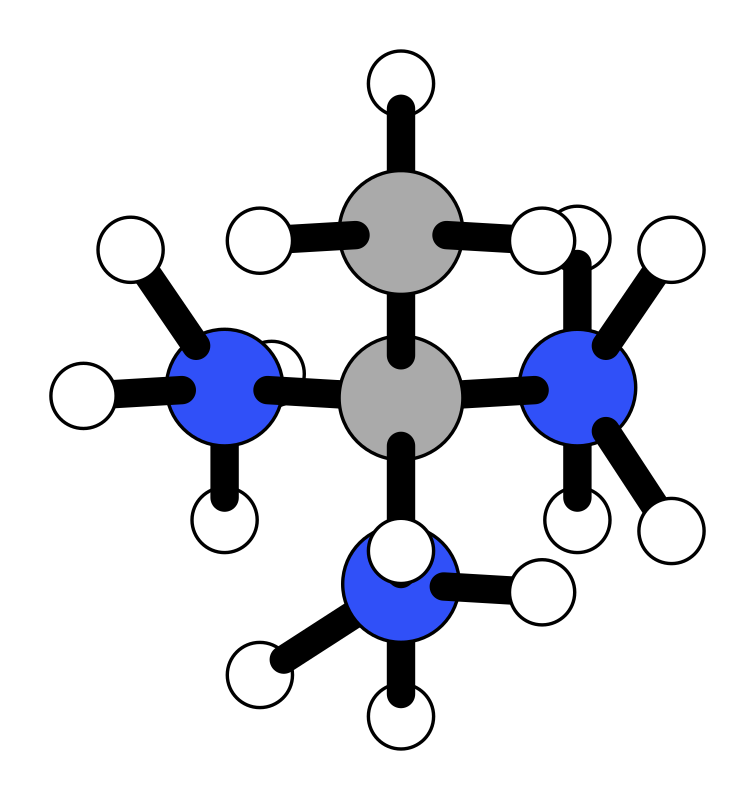

In [44]:
mol = load(file_out)
render(mol, output=file_svg, config=cfg)